In [3]:
import pandas as pd
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

In [4]:
def extract_data(filedir):
    files = os.listdir(filedir)
    df_list = [pd.read_csv(os.path.join(filedir, f), header=None, names=list(range(23))) for f in files if f.endswith('.csv')]
    df_list = [df.drop(0) for df in df_list]
    df_list = [df.drop(df.columns[list(range(-1, -9, -1))], axis=1) for df in df_list]
    data = pd.concat(df_list, ignore_index=True)    
    return data


dir1 = "F:/IMU_computational_ethology/Data/2mouse_imu_83label/Data1_83"
dir2 = "F:/IMU_computational_ethology/Data/2mouse_imu_83label/Data2_e8"


data1 = extract_data(dir1)
data2 = extract_data(dir2)

print(data1.shape)
print(data2.shape)

C:\Users\Shubai\AppData\Local\Temp\ipykernel_3216\3205637938.py:3: DtypeWarning: Columns (3,4,5,6,7,8,9,10,11,12,13,14,15,20,21) have mixed types. Specify dtype option on import or set low_memory=False.
  df_list = [pd.read_csv(os.path.join(filedir, f), header=None, names=list(range(23))) for f in files if f.endswith('.csv')]
C:\Users\Shubai\AppData\Local\Temp\ipykernel_3216\3205637938.py:3: DtypeWarning: Columns (3,4,5,6,7,8,9,10,11,12,13,14,15,20,21) have mixed types. Specify dtype option on import or set low_memory=False.
  df_list = [pd.read_csv(os.path.join(filedir, f), header=None, names=list(range(23))) for f in files if f.endswith('.csv')]
C:\Users\Shubai\AppData\Local\Temp\ipykernel_3216\3205637938.py:3: DtypeWarning: Columns (3,4,5,6,7,8,9,10,11,12,13,14,15,20,21) have mixed types. Specify dtype option on import or set low_memory=False.
  df_list = [pd.read_csv(os.path.join(filedir, f), header=None, names=list(range(23))) for f in files if f.endswith('.csv')]
C:\Users\Shubai\

(461628, 15)
(460404, 15)


In [5]:
def time_transform(arr):

    arr = np.array([t.replace(":", ".").split(".") for t in arr], dtype=float)
    secs = arr[:,0]*3600 + arr[:,1]*60 + arr[:,2] + arr[:,3]/1000
    return secs

In [6]:
time_onchip1 = time_transform([x.split(" ", 2)[2] for x in data1[2]])
time_onchip2 = time_transform([x.split(" ", 2)[2] for x in data2[2]])


time_sys1 = time_transform(data1[0])
time_sys2 = time_transform(data2[0])


In [55]:
print(time_onchip1[:5])

[1014.56 1014.57 1014.58 1014.59 1014.6 ]


In [7]:
t1 = time_onchip1
t2 = time_onchip2


def frameloss_test(t):
    fl_count = 0
    lostframes = 0 
    for i in range(1, len(t)):
        if float(t[i]) - float(t[i-1]) >= 0.02:
            fl_count += 1
            lostframes += int((t[i] - t[i-1]) / 0.01) - 1
            #print(f"Frame loss between {i-1} and {i}: {t[i] - t[i-1]:.3f} seconds")        
    print(f"frame loss count: {fl_count}")
    print(f"total lost frames: {lostframes}")

frameloss_test(t1)
frameloss_test(t2)


frame loss count: 223
total lost frames: 93373806
frame loss count: 335
total lost frames: 2699


In [8]:
import numpy as np
from scipy.interpolate import PchipInterpolator

def align_imu(data):
    """
    data: ndarray, 列0=系统时间, 列2=片上时间, 列3:15=信号(12通道)
    返回: t_new, out, fs, drift
    """
    # 强制数值化，避免字符串输入
    ts = data[:, 0]
    ts = np.array([t.replace(":", ".").split(".") for t in ts], dtype=float)
    ts = ts[:,0]*3600 + ts[:,1]*60 + ts[:,2] + ts[:,3]/1000
    
    tc = data[:, 2]
    tc = [x.split(" ", 2)[2] for x in tc]
    tc = np.array([t.replace(":", ".").split(".") for t in tc], dtype=float)
    tc = tc[:,0]*3600 + tc[:,1]*60 + tc[:,2] + tc[:,3]/1000

    sig = data[:, 3:15].astype(np.float64)
    
    # 1. 清洗片上时间异常
    dt = np.diff(tc)
    ok = np.concatenate(([True], (dt > 0) & (dt < 0.5)))
    ts, tc, sig = ts[ok], tc[ok], sig[ok]
    
    # 2. 晶振频偏拟合
    k, b = np.polyfit(ts, tc, 1)
    fs = 100.0 * k
    drift = (1.0 - k) * 100
    
    # 3. 反解平滑真实时间轴
    t_est = (tc - b) / k
    
    # 4. 等间隔目标轴
    dt = 1.0 / fs
    t_new = np.arange(t_est[0], t_est[-1] + dt/2, dt)
    
    out = np.zeros((len(t_new), sig.shape[1]))
    for i in range(sig.shape[1]):
        pchip = PchipInterpolator(t_est, sig[:, i])
        out[:, i] = pchip(t_new)
    
    return t_new, out, sig, fs, drift, t_est

In [9]:
t_new1, sig1, sig_ori1, fs1, drift1, t_est1 = align_imu(data1.values)
t_new2, sig2, sig_ori2, fs2, drift2, t_est2 = align_imu(data2.values)

**这里插入行为子空间分析的部分**


In [10]:
t_new1 = t_new1-t_new1[0]
t_new2 = t_new2-t_new2[0]

In [11]:

ta = t_new1 - 7  
tb = t_new2 - 7  



In [12]:
ta_p = ta[ta >= 0]
ndrop = len(ta) - len(ta_p)
imu_a = sig1[-len(ta_p):]

tb_p = tb[tb >= 0]
ndrop = len(tb) - len(tb_p)
imu_b = sig2[-len(tb_p):]





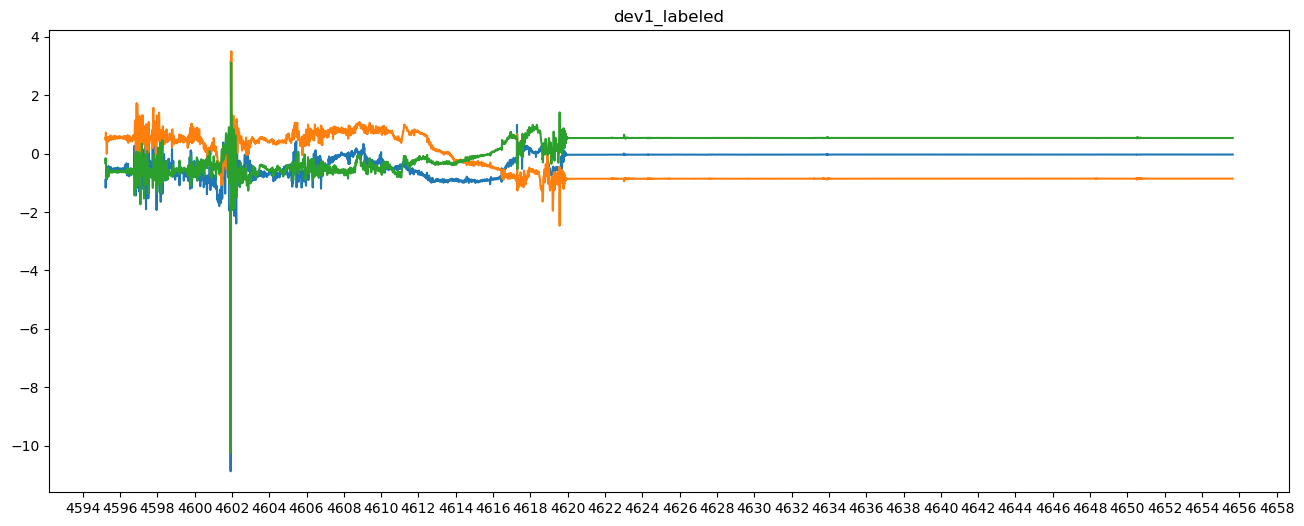

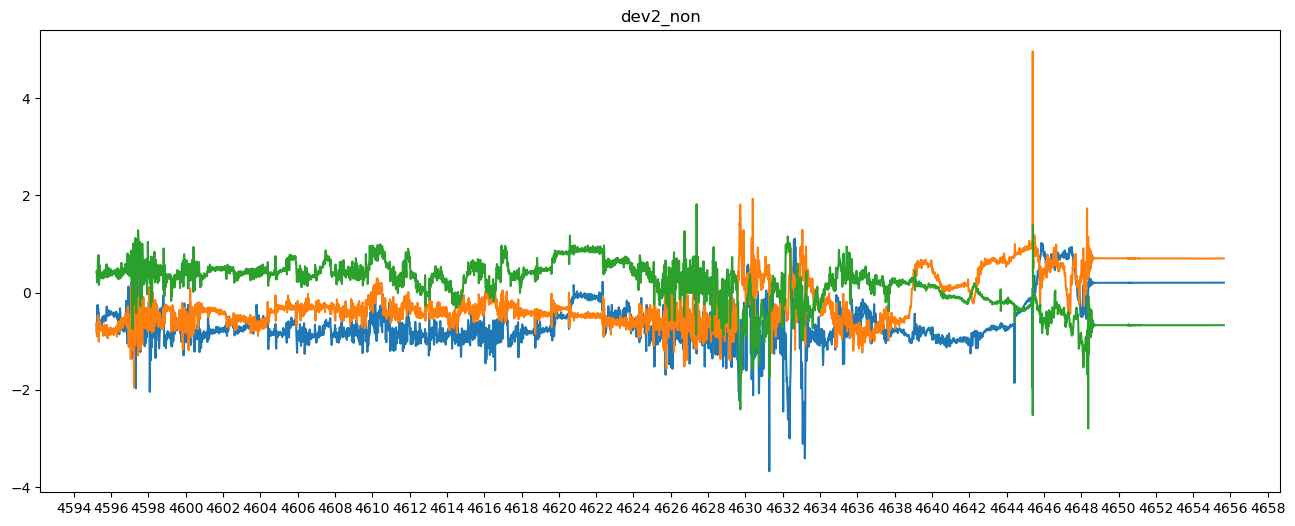

In [ ]:
#绘图检查时间和视频对应关系
import matplotlib.pyplot as plt

start = -7000
end = -1000
figsize = (16, 6)

fig, ax = plt.subplots()
ax.figure.set_size_inches(figsize)
ax.plot(t_new1[start:end], sig1[start:end,0])
ax.plot(t_new1[start:end], sig1[start:end,1])
ax.plot(t_new1[start:end], sig1[start:end,2])
ax.xaxis.set_major_locator(plt.MultipleLocator(2))  # 间隔改为1
plt.title("dev1_labeled")
plt.show()

fig, ax = plt.subplots()
ax.figure.set_size_inches(figsize)
ax.plot(t_new2[start:end], sig2[start:end,0])
ax.plot(t_new2[start:end], sig2[start:end,1])
ax.plot(t_new2[start:end], sig2[start:end,2])
ax.xaxis.set_major_locator(plt.MultipleLocator(2))
plt.title("dev2_non")
plt.show()


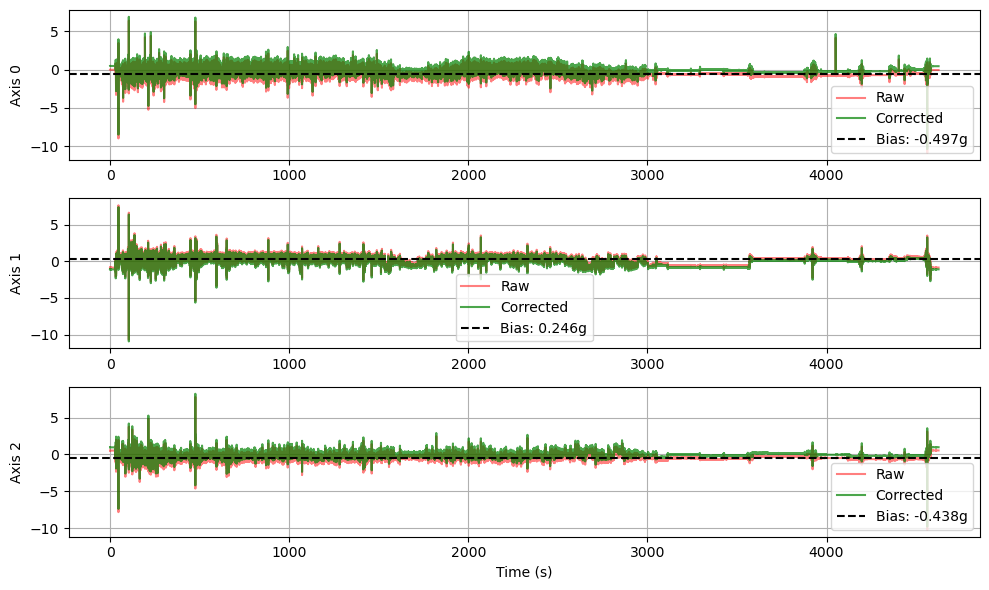

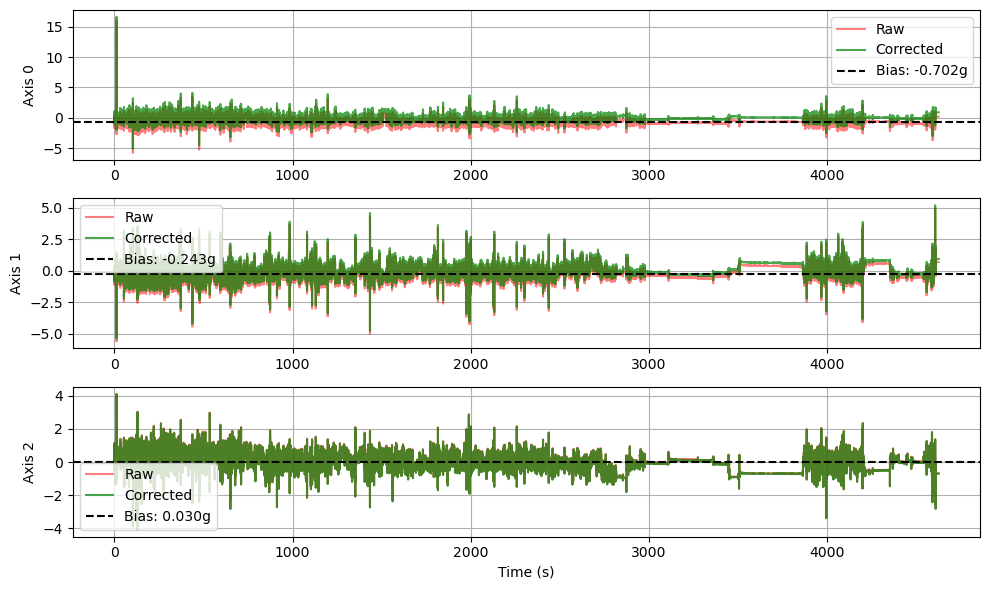

In [13]:
#重力偏移校正（暂时不需要，在DISSeCT方法中，直接跳到下一步构建AG和AnG）
import numpy as np
from scipy.signal import butter, filtfilt
import matplotlib.pyplot as plt

def correct_imu_simple(data_9col, fs=100, cutoff=0.1):
    """
    最简IMU校正：9列输入 -> 校正后9列输出
    仅校正加速度前3列，陀螺仪后3列保持不变
    """
    acc = data_9col[:, :3].copy()
    
    # 零偏估计：低通滤波
    nyquist = 0.5 * fs
    b, a = butter(2, cutoff/nyquist, btype='low')
    bias = np.array([np.mean(filtfilt(b, a, acc[:, i])) for i in range(3)])
    
    # 校正
    acc_corrected = acc - bias
    
    # 合并输出
    result = data_9col.copy()
    result[:, :3] = acc_corrected
    
    # 可视化
    fig, ax = plt.subplots(3, 1, figsize=(10, 6))
    t = np.arange(len(acc)) / fs
    for i in range(3):
        ax[i].plot(t, acc[:, i], 'r', alpha=0.5, label='Raw')
        ax[i].plot(t, acc_corrected[:, i], 'g', alpha=0.7, label='Corrected')
        ax[i].axhline(bias[i], color='k', linestyle='--', label=f'Bias: {bias[i]:.3f}g')
        ax[i].set_ylabel(f'Axis {i}')
        ax[i].legend()
        ax[i].grid(True)
    ax[2].set_xlabel('Time (s)')
    plt.tight_layout()
    plt.savefig('correction_result.png')
    
    return result, bias


imu_a1, estimated_bias1 = correct_imu_simple(imu_a, fs=100)
imu_b1, estimated_bias2 = correct_imu_simple(imu_b, fs=100)

In [14]:
#IMU数据预处理，从原始数据建立AG、AnG和w
import numpy as np

def preprocess_segment(data):
    """
    单段 9 轴 IMU 预处理。
    
    输入
    ----
    data : np.ndarray, shape (n, 9)
        列顺序: [ax, ay, az, wx, wy, wz, roll, pitch, yaw]
        单位: 加速度(g), 角速度(°/s), 角度(°)
        
    输出
    ----
    np.ndarray, shape (n, 9)
        列顺序: [aGx, aGy, aGz, anGx, anGy, anGz, wx, wy, wz]
    """
    a_raw = data[:, 0:3].astype(float)
    w_raw = data[:, 3:6].astype(float)
    r_deg = data[:, 6:9].astype(float)

    # 1. 陀螺仪零偏：整段中位数（角速度理论上均值为0）
    w = w_raw - np.median(w_raw, axis=0)

    # 2. 欧拉角 -> 旋转矩阵 R (head -> Earth, ZYX 内旋: yaw→pitch→roll)
    #    如果传感器角度顺序不同，请修改此矩阵
    r = np.radians(r_deg)
    cr, sr = np.cos(r[:, 0]), np.sin(r[:, 0])   # roll
    cp, sp = np.cos(r[:, 1]), np.sin(r[:, 1])   # pitch
    cy, sy = np.cos(r[:, 2]), np.sin(r[:, 2])   # yaw

    R = np.zeros((len(data), 3, 3))
    R[:, 0, 0] = cy * cp
    R[:, 0, 1] = cy * sp * sr - sy * cr
    R[:, 0, 2] = cy * sp * cr + sy * sr
    R[:, 1, 0] = sy * cp
    R[:, 1, 1] = sy * sp * sr + cy * cr
    R[:, 1, 2] = sy * sp * cr - cy * sr
    R[:, 2, 0] = -sp
    R[:, 2, 1] = cp * sr
    R[:, 2, 2] = cp * cr

    # 3. 头部参考系中的重力分量 aG = R^T · [0, 0, 1]
    aG = np.einsum('nij,j->ni', R.transpose(0, 2, 1), np.array([0., 0., 1.]))

    # 验证：aG 模长必须恒为 1.0。若报错，说明角度顺序/定义与代码不符
    assert np.allclose(np.linalg.norm(aG, axis=1), 1.0, atol=0.05), \
        "aG 模长不恒为 1g，请检查 roll/pitch/yaw 是否为 ZYX 内旋顺序"

    # 4. 加速度零偏：利用 anG 应近似零均值的特性
    #    a_raw = aG + anG_true + bias  =>  a_raw - aG = anG_true + bias
    #    取中位数即可分离出 bias（假设真实运动加速度 anG_true 的中位数为0）
    acc_bias = np.median(a_raw - aG, axis=0)
    a = a_raw - acc_bias

    # 5. 非重力加速度
    anG = a - aG

    return np.concatenate([aG, anG, w], axis=1)

In [15]:
imu_preprocessed1 = preprocess_segment(imu_a)
imu_preprocessed2 = preprocess_segment(imu_b)

In [21]:
#DISSeCT变点检测
import numpy as np
import ruptures as rpt


def dissect_imu(imu_data, timestamps, fs, pen=None):
    imu_data_1= np.concatenate([imu_data[:, 0:3], imu_data[:, 6:9]], axis=1)
    """
    基于 DISSeCT 的变点检测，将六轴 IMU 时间序列切割为片段。

    Parameters
    ----------
    imu_data : np.ndarray, shape (n_samples, 6)
        6 列 IMU 数据，列顺序建议为 [acc_x, acc_y, acc_z, gyro_x, gyro_y, gyro_z]。
    timestamps : np.ndarray, shape (n_samples,)
        每个采样点对应的真实时间戳，需与时间序列顺序一致。
    fs : float
        采样率（Hz）。
    pen : float, optional
        PELT 算法的惩罚系数。默认 None 时，按原文经验自动估算
        （大鼠 300 Hz → 14；小鼠 200 Hz → 9，比例约为 0.045 × fs），
        使片段中位时长落在 300–400 ms 附近。pen 越大片段越长。

    Returns
    -------
    segments : dict
        键为按顺序编号的字符串 'seg_0', 'seg_1', ...
        每个键对应的值为字典，包含：
            - 'data'      : np.ndarray, shape (m, 6)
            - 'timestamps': np.ndarray, shape (m,)
    """
    # 对每一列分别做 z-score 标准化（与原文一致）
    mu = np.mean(imu_data_1, axis=0)
    sigma = np.std(imu_data_1, axis=0)
    sigma[sigma == 0] = 1.0
    data_z = (imu_data_1 - mu) / sigma

    # 若未指定 pen，按采样率线性估算，目标中位片段时长约 350 ms
    if pen is None:
        pen = fs * 0.045

    # 最小片段长度：约 50 ms（或至少 3 个采样点），避免过短片段
    min_size = max(int(fs * 0.05), 3)

    # 使用 PELT + Gaussian RBF kernel 进行变点检测
    algo = rpt.Pelt(model="rbf", min_size=min_size, jump=1)
    algo.fit(data_z)
    bkps = algo.predict(pen=pen)

    # 按变点索引切片，生成编号变量
    segments = {}
    start = 0
    for idx, end in enumerate(bkps):
        key = f"seg_{idx}"
        segments[key] = {
            "data": imu_data[start:end, :],
            "timestamps": timestamps[start:end]
        }
        start = end

    return segments





In [19]:
#将数据切割为2min的片段

def segment(t, imu):
    data_seg = []
    t_seg = []
    seg_len = 120
    edges = np.arange(t[0] // seg_len * seg_len, t[-1] + seg_len, seg_len)
    ix = np.searchsorted(t, edges)

    for s, e in zip(ix, ix[1:]):
        if e <= s: continue
        ti, imui = t[s:e], imu[s:e]
        # 处理该段：满10min或不足10min的尾段均保留
        data_seg.append(imui)
        t_seg.append(ti)
    return data_seg, t_seg


seg_data1, seg_t1 = segment(ta_p, imu_preprocessed1)
seg_data2, seg_t2 = segment(tb_p, imu_preprocessed2)


In [22]:
index = 2 #选择第3段进行变点检测

CPDsegments1 = dissect_imu(seg_data1[index], seg_t1[index], fs=100)
CPDsegments2 = dissect_imu(seg_data2[index], seg_t2[index], fs=100)



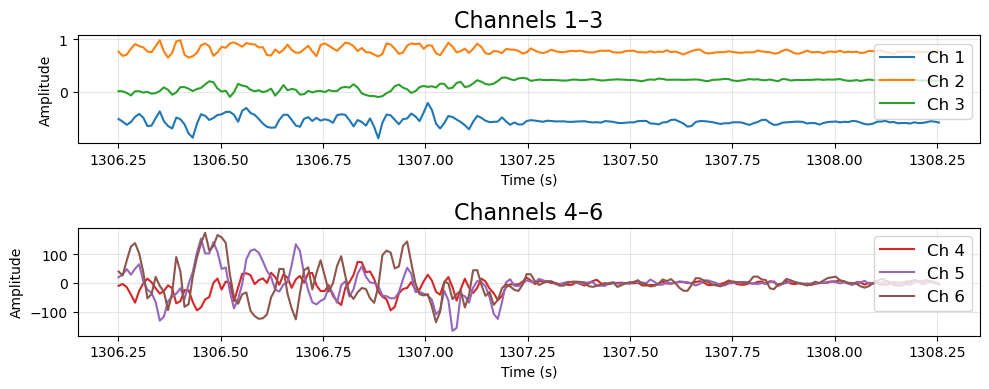

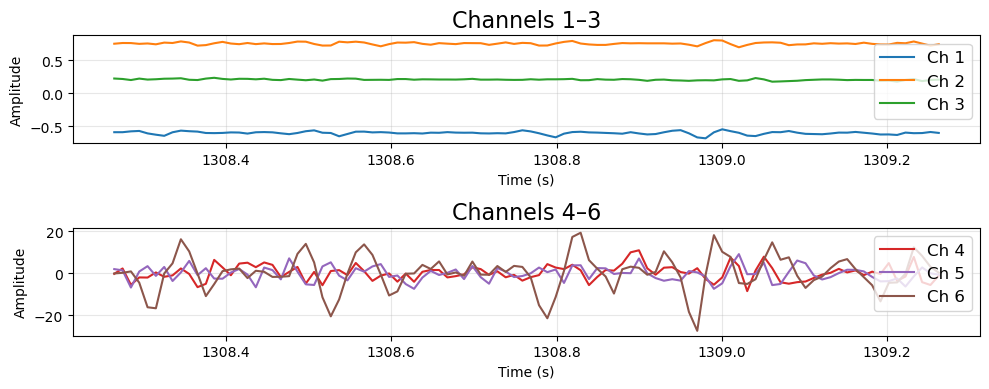

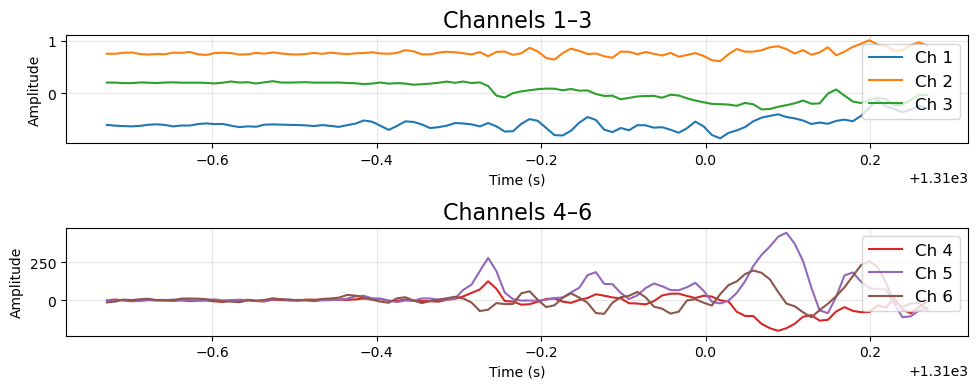

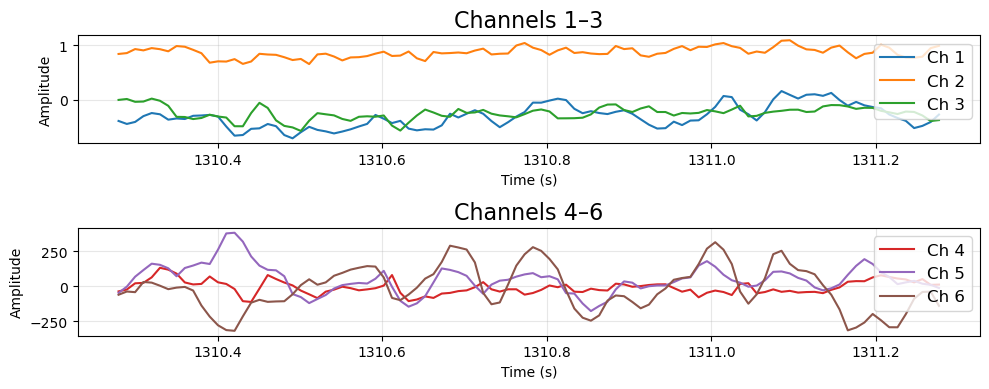

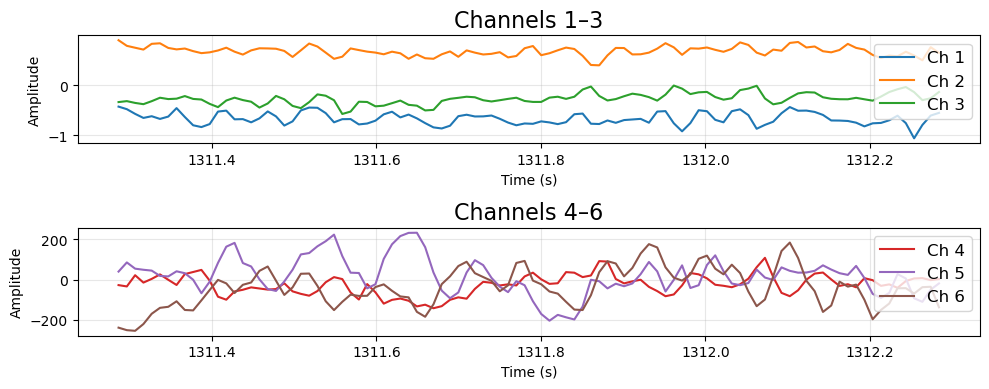

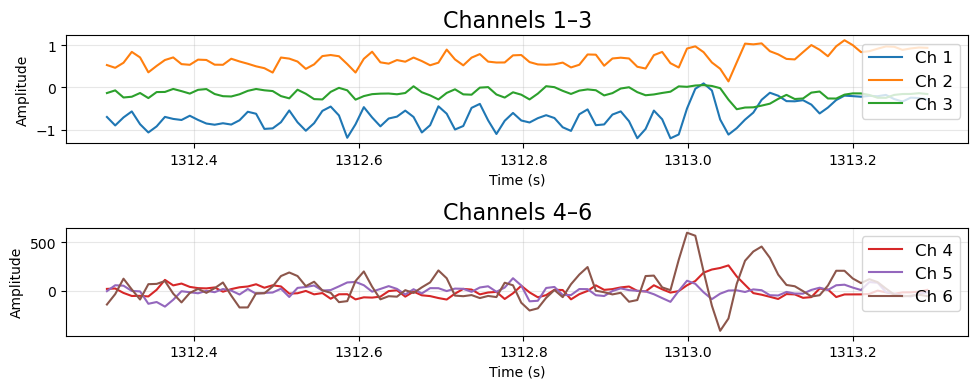

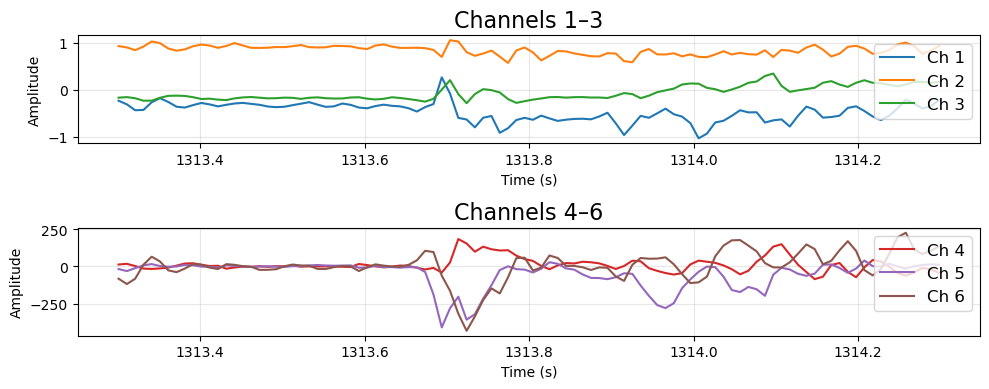

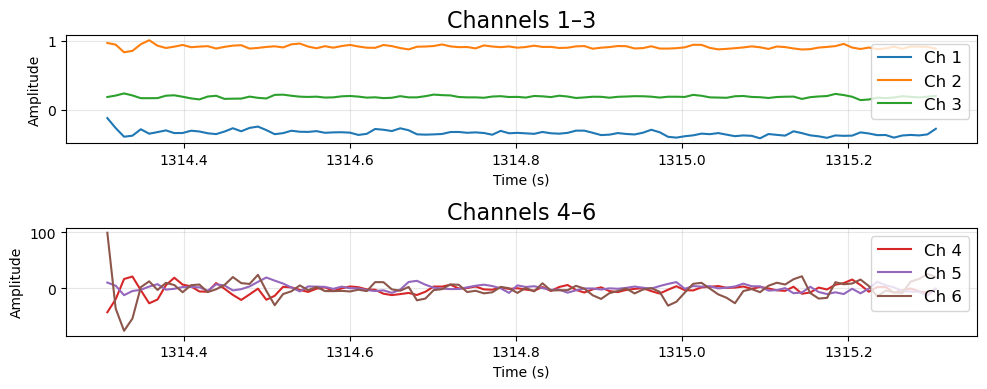

In [ ]:
#分别绘制每一段的信号
import numpy as np
import matplotlib.pyplot as plt

colors_ch13 = ['#1f77b4', '#ff7f0e', '#2ca02c']  # Ch1–3
colors_ch46 = ['#d62728', '#9467bd', '#8c564b']  # Ch4–6

for i in range(8):
    key = f"seg_{i}"
    seg = segments2[key]
    data = seg["data"]
    ts = seg["timestamps"]

    fig, axs = plt.subplots(2, 1, figsize=(10, 4))

    # 第一行：通道 1–3 共轴
    for j in range(3):
        axs[0].plot(ts, data[:, j], color=colors_ch13[j], lw=1.5, label=f"Ch {j+1}")
    axs[0].set_title("Channels 1–3", fontsize=16)
    axs[0].set_xlabel("Time (s)")
    axs[0].set_ylabel("Amplitude")
    axs[0].legend(loc='upper right', fontsize=12)
    axs[0].grid(True, alpha=0.3)

    # 第二行：通道 4–6 共轴
    for j in range(3):
        axs[1].plot(ts, data[:, j+3], color=colors_ch46[j], lw=1.5, label=f"Ch {j+4}")
    axs[1].set_title("Channels 4–6", fontsize=16)
    axs[1].set_xlabel("Time (s)")
    axs[1].set_ylabel("Amplitude")
    axs[1].legend(loc='upper right', fontsize=12)
    axs[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()
    plt.close()

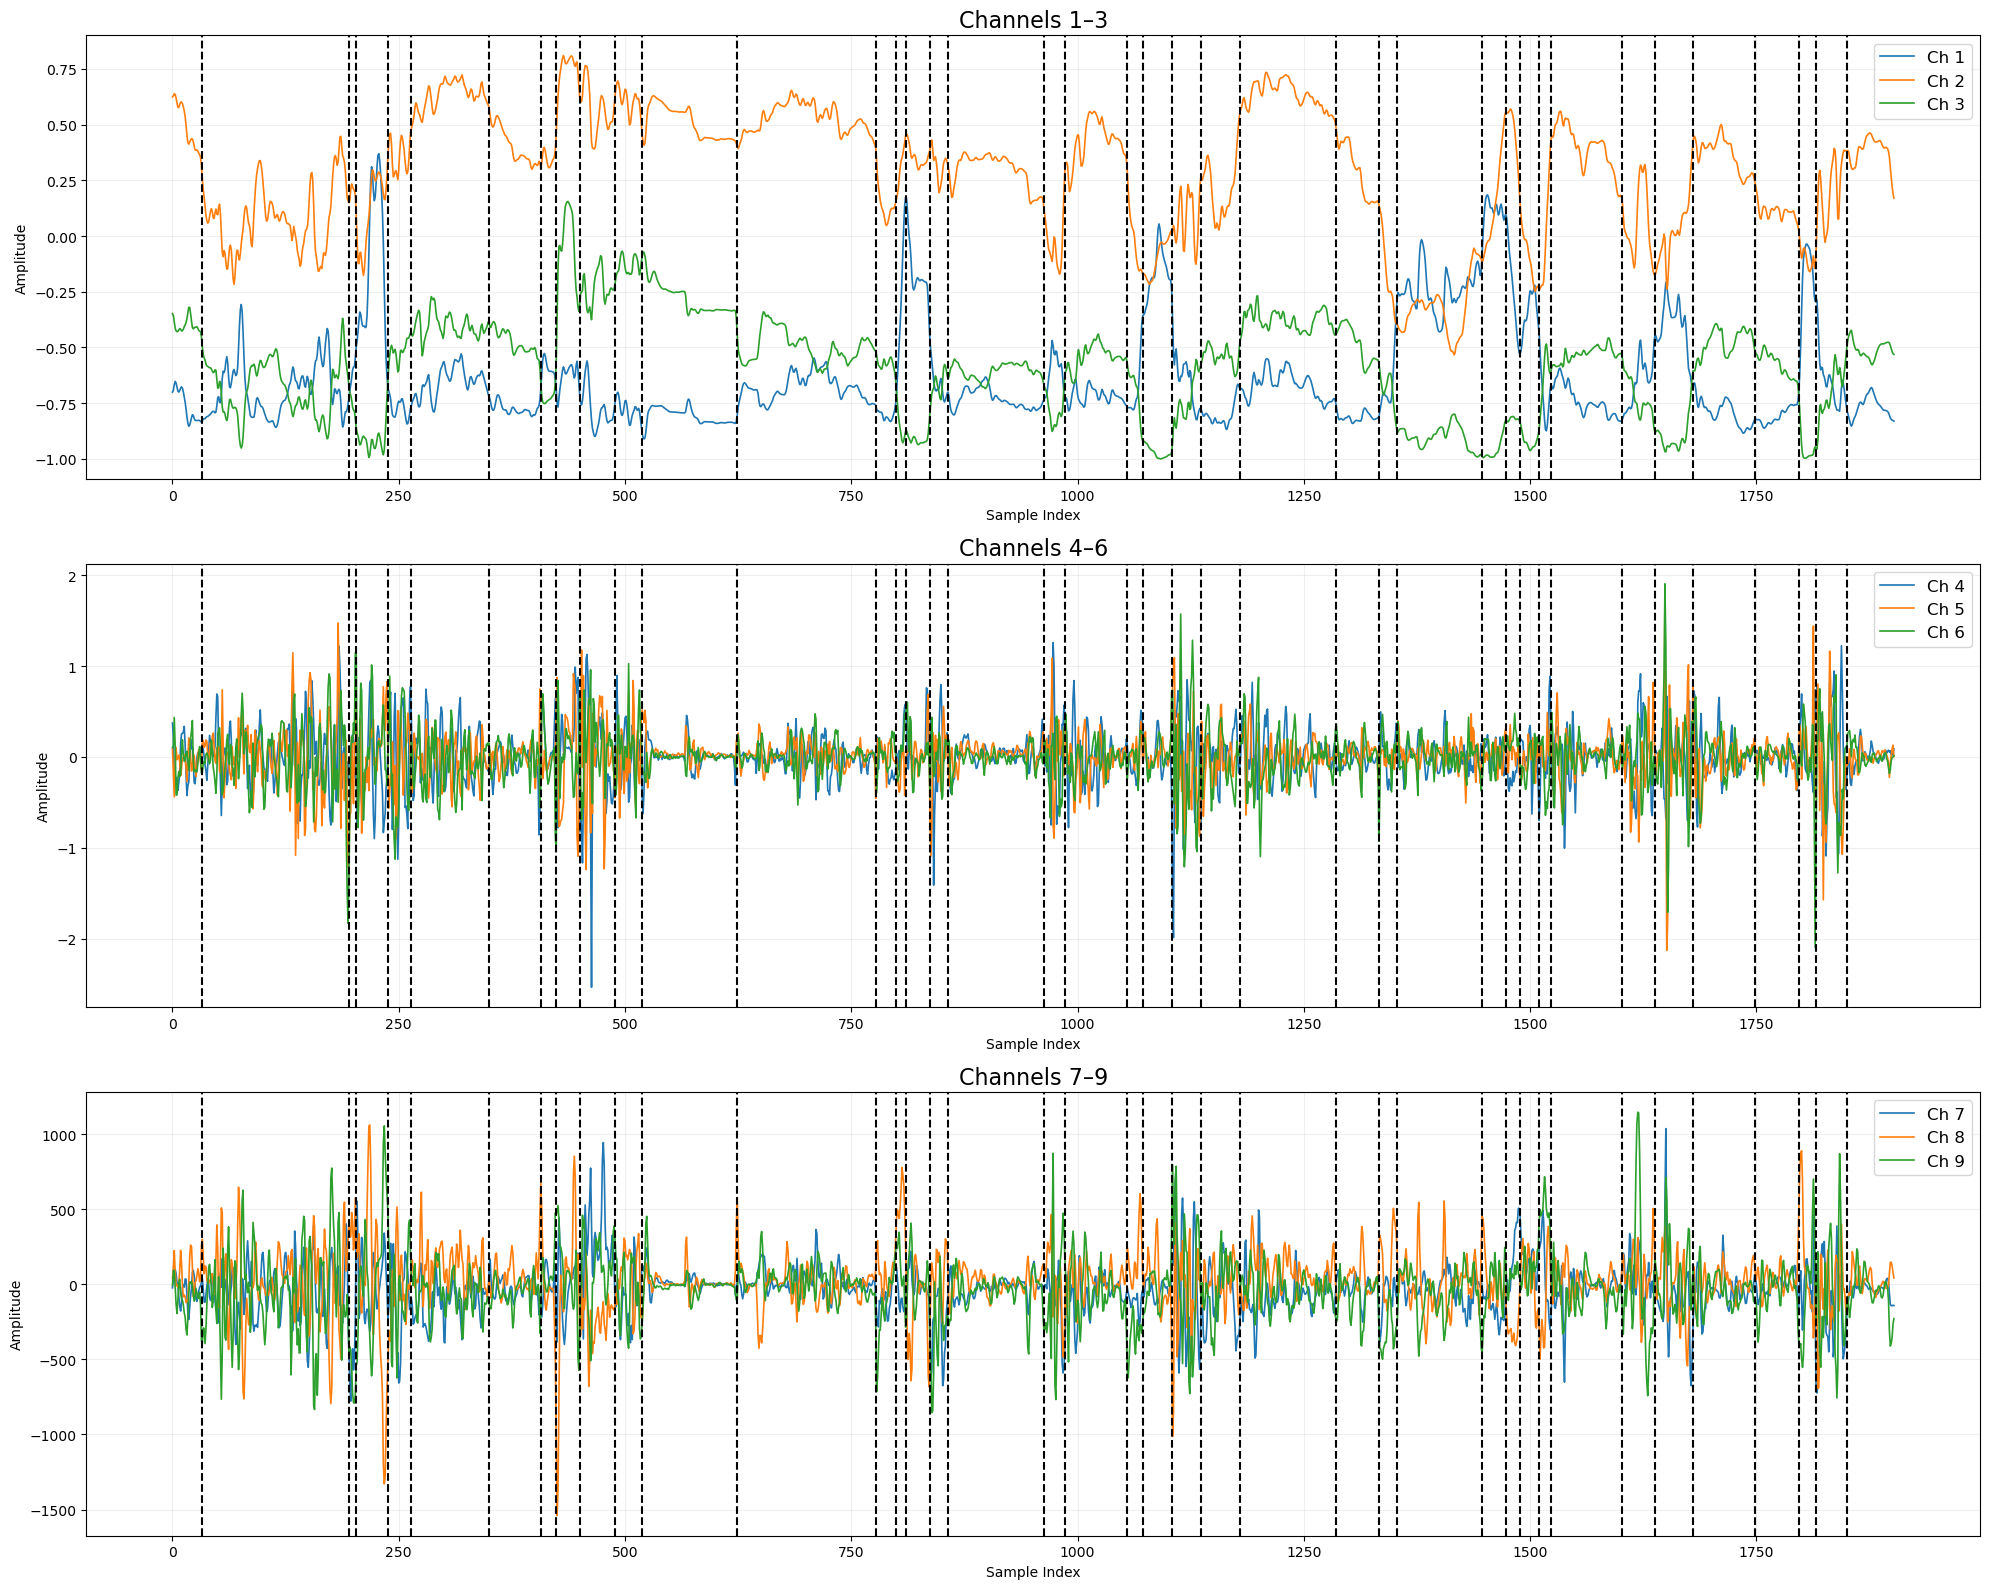

In [24]:
#绘制所有片段的拼接图（DISSeCT）
import numpy as np
import matplotlib.pyplot as plt

# 拼接所有片段
data_list = []
boundaries = [0]
for i in range(40):
    seg = CPDsegments1[f"seg_{i}"]
    data_list.append(seg["data"])
    boundaries.append(boundaries[-1] + len(seg["data"]))

all_data = np.concatenate(data_list, axis=0)
x = np.arange(len(all_data))
boundary_x = boundaries[1:-1]  # 片段间边界索引

colors_13 = ['#1f77b4', '#ff7f0e', '#2ca02c']
colors_46 = ['#1f77b4', '#ff7f0e', '#2ca02c']
colors_79 = ['#1f77b4', '#ff7f0e', '#2ca02c'] # Ch7–9

fig, axs = plt.subplots(3, 1, figsize=(20, 16))

# 第一行：通道 1–3
for j in range(3):
    axs[0].plot(x, all_data[:, j], color=colors_13[j], lw=1.2, label=f"Ch {j+1}")
for bx in boundary_x:
    axs[0].axvline(bx, color='black', linestyle='--', lw=1.5)
axs[0].set_title("Channels 1–3", fontsize=16)
axs[0].set_xlabel("Sample Index")
axs[0].set_ylabel("Amplitude")
axs[0].legend(loc='upper right', fontsize=12)
axs[0].grid(True, alpha=0.2)

# 第二行：通道 4–6
for j in range(3):
    axs[1].plot(x, all_data[:, j+3], color=colors_46[j], lw=1.2, label=f"Ch {j+4}")
for bx in boundary_x:
    axs[1].axvline(bx, color='black', linestyle='--', lw=1.5)
axs[1].set_title("Channels 4–6", fontsize=16)
axs[1].set_xlabel("Sample Index")
axs[1].set_ylabel("Amplitude")
axs[1].legend(loc='upper right', fontsize=12)
axs[1].grid(True, alpha=0.2)

# 第三行：通道 7–9
for j in range(3):
    axs[2].plot(x, all_data[:, j+6], color=colors_46[j], lw=1.2, label=f"Ch {j+7}")
for bx in boundary_x:
    axs[2].axvline(bx, color='black', linestyle='--', lw=1.5)
axs[2].set_title("Channels 7–9", fontsize=16)
axs[2].set_xlabel("Sample Index")
axs[2].set_ylabel("Amplitude")
axs[2].legend(loc='upper right', fontsize=12)
axs[2].grid(True, alpha=0.2)

plt.tight_layout()
plt.show()
plt.close()

In [ ]:
sig1_preprocessed = preprocess_segment(CPDsegments1["seg_0"])

In [ ]:
extraction_test = CPDsegments1["seg_2"]["data"]



In [ ]:
import numpy as np
from numpy.linalg import norm
"""
数据结构：9轴，
分别为3轴AG、AnG、Ω
0.数据标准化：仅对AG、Ω做标准化

特征提取内容:
1.每个片段Ω AG AnG(9轴)的均值、标准差、最小值、最大值、中位数、四分位数；
2.Ω和AnG（6轴）的估计梯度和L2范数
3.Ω和AnG（6轴）之间两两相关系数
4.

"""

def extract_features(seg_data, fs=100):
    channels = []
    feats = []
    
    for ch in range(3,6):
        x = seg_data[:, ch]
        channels +=  [x]
    
    for ch in range(9):
        x = seg_data[:, ch]
        gradx = np.gradient(x, 1/fs)
        channels += [gradx]
    
    norm_w = np.linalg.norm(seg_data[:, 6:9], axis=1)
    norm_ang = np.linalg.norm(seg_data[:, 3:6], axis=1)
    channels += [norm_w, norm_ang]
    #构建20类数据

    print(len(channels))
    for ch in channels:
        mean = np.mean(ch)
        std = np.std(ch)
        max = np.max(ch)
        min = np.min(ch)
        median = np.median(ch)
        q25 = np.percentile(ch, 25)
        q75 = np.percentile(d, 75)             
        feats += [mean, std, min, max, median, q25, q75]
    #提取20维数据的7个特征，共140个特征

    duration = seg_data.shape[0]
    log_duration = np.log10(duration)
    feats += log_duration
    #每段时长与对数时长，2个特征

    corr = np.corrcoef(seg_data[:, 3:9].T)[np.triu_indices(6, k=1)]
    feats += corr.tolist()
    #Ω和AnG的两两相关性，15个特征

    for ch in range(6,9):
        x = seg_data[:, ch]
        energy = np.sum(x ** 2)
    






    

extract_features(extraction_test)

20
155


In [ ]:
#特征提取
import os
import numpy as np
from scipy import stats
from sklearn.mixture import GaussianMixture
from sklearn.decomposition import PCA
from sklearn.model_selection import KFold
import matplotlib.pyplot as plt
from tqdm import tqdm


"""
特征提取内容:
1.每个片段Ω AG AnG(9轴)的均值、标准差、最小值、最大值、中位数、四分位数；
2.Ω和AnG（6轴）的估计梯度和L2范数
3.Ω和AnG（6轴）之间两两相关系数
4.

"""
# ==================== 1. 特征提取 ====================

def extract_features(seg_data, fs):
    n = seg_data.shape[0]
    feats = []

    for ch in range(9):
        x = seg_data[:, ch]
        if n > 1 and np.std(x) > 0:
            feats += [
                np.mean(x), np.std(x), np.min(x), np.max(x), np.median(x),
                np.percentile(x, 25),np.percentile(x, 75), 
                np.max(x) - np.min(x),
                stats.skew(x), stats.kurtosis(x),
                np.sqrt(np.mean(x ** 2)),               # RMS
                np.sum(x ** 2),                        # energy
                np.mean(np.abs(x)), np.max(np.abs(x)), np.std(np.abs(x)),
                np.polyfit(np.arange(n), x, 1)[0],     # linear trend
            ]
        else:
            feats += [0.0] * 19

    # --- 1.2 单通道频域特征 (6 x 13 = 78) ---
    n_fft = max(256, 2 ** int(np.ceil(np.log2(n))))
    for ch in range(6):
        x = seg_data[:, ch]
        if n > 1 and np.std(x) > 0:
            fft_vals = np.fft.rfft(x - np.mean(x), n=n_fft)
            ps = np.abs(fft_vals) ** 2 + 1e-12
            freqs = np.fft.rfftfreq(n_fft, 1 / fs)
            total = np.sum(ps)

            # 5 个频带能量占比
            bands = [(0, 2), (2, 5), (5, 10), (10, 20), (20, fs / 2)]
            bp = [np.sum(ps[(freqs >= lo) & (freqs < hi)]) / total for lo, hi in bands]

            centroid = np.sum(freqs * ps) / total
            peak_f = freqs[np.argmax(ps)]
            bandwidth = np.sqrt(np.sum((freqs - centroid) ** 2 * ps) / total)
            peak_ratio = np.max(ps) / total
            top3 = np.sort(ps / total)[-3:][::-1]

            # 频谱熵
            ps_norm = ps / total
            spec_entropy = -np.sum(ps_norm * np.log(ps_norm + 1e-12))

            feats += bp + [centroid, peak_f, bandwidth, peak_ratio, spec_entropy] + list(top3)
        else:
            feats += [0.0] * 13

    # --- 1.3 跨通道特征 (~48) ---
    acc = seg_data[:, :3]
    gyro = seg_data[:, 3:]
    if n > 1:
        # 协方差矩阵上三角
        for mat in [np.cov(acc.T), np.cov(gyro.T)]:
            if mat.shape == (3, 3):
                feats += list(mat[np.triu_indices(3)])
            else:
                feats += [0.0] * 6

        # acc-gyro 互相关 (9)
        for i in range(3):
            for j in range(3):
                a, g = acc[:, i], gyro[:, j]
                if np.std(a) > 0 and np.std(g) > 0:
                    feats.append(np.corrcoef(a, g)[0, 1])
                else:
                    feats.append(0.0)

        # 合向量统计 (11)
        norm_acc = np.linalg.norm(acc, axis=1)
        norm_gyro = np.linalg.norm(gyro, axis=1)
        for v in [norm_acc, norm_gyro]:
            feats += [np.mean(v), np.std(v), np.max(v), np.min(v), np.sqrt(np.mean(v ** 2))]
        if np.std(norm_acc) > 0 and np.std(norm_gyro) > 0:
            feats.append(np.corrcoef(norm_acc, norm_gyro)[0, 1])
        else:
            feats.append(0.0)

        # 内部平均相关 (2)
        acc_corr = np.corrcoef(acc.T) if acc.shape[1] > 1 else np.eye(3)
        gyro_corr = np.corrcoef(gyro.T) if gyro.shape[1] > 1 else np.eye(3)
        mask_triu = np.triu_indices(3, k=1)
        feats.append(np.mean(acc_corr[mask_triu]) if acc_corr.shape == (3, 3) else 0.0)
        feats.append(np.mean(gyro_corr[mask_triu]) if gyro_corr.shape == (3, 3) else 0.0)

        # 差分特征 (8)
        diff = np.diff(seg_data, axis=0)
        for ch in range(6):
            feats.append(np.std(diff[:, ch]) if diff.shape[0] > 0 else 0.0)
        feats.append(np.mean(np.linalg.norm(diff[:, :3], axis=1)) if diff.shape[0] > 0 else 0.0)
        feats.append(np.mean(np.linalg.norm(diff[:, 3:], axis=1)) if diff.shape[0] > 0 else 0.0)
    else:
        feats += [0.0] * 48

    # --- 1.4 信号直方图熵 (6) ---
    for ch in range(6):
        x = seg_data[:, ch]
        if n > 1 and np.std(x) > 0:
            hist, _ = np.histogram(x, bins=10, density=True)
            hist = hist[hist > 0]
            entropy = -np.sum(hist * np.log(hist + 1e-12))
            feats.append(entropy)
        else:
            feats.append(0.0)

    return np.array(feats, dtype=np.float32)


# ==================== 2. PCA 交叉验证选主成分数 ====================

def select_pca_n_components(X, max_comp=50, n_splits=3):
    """
    简化版交叉验证（参考 Josse & Husson 2012），在训练集拟合 PCA，
    在测试集计算重构误差，选择误差最小的主成分数。
    """
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)
    best_n = 5
    best_err = np.inf
    search_range = list(range(5, min(max_comp, X.shape[1]) + 1, 5))

    for n in search_range:
        errs = []
        for tr_idx, te_idx in kf.split(X):
            pca = PCA(n_components=n)
            pca.fit(X[tr_idx])
            proj = pca.transform(X[te_idx])
            rec = pca.inverse_transform(proj)
            errs.append(np.mean((X[te_idx] - rec) ** 2))
        if np.mean(errs) < best_err:
            best_err = np.mean(errs)
            best_n = n
    return best_n


# ==================== 3. 核心聚类流程 ====================

def dissect_cluster(segments, fs=100.0, pca_n=None):
    """
    DISSeCT 风格的无监督聚类（修复版）。
    """
    keys = list(segments.keys())

    # ---- 3.1 特征提取 ----
    print("Extracting features from segments...")
    X = []
    for k in tqdm(keys, desc="Feature extraction"):
        feat = extract_features(segments[k]['data'], fs)
        X.append(feat)
    X = np.vstack(X).astype(np.float64)  # 使用 float64 提高数值稳定性

    # ---- 3.2 异常值剔除 ----
    med = np.median(X, axis=0)
    q75 = np.percentile(X, 75, axis=0)
    q25 = np.percentile(X, 25, axis=0)
    iqr = q75 - q25
    iqr[iqr == 0] = 1.0
    X_robust = (X - med) / iqr
    mask = np.all(np.abs(X_robust) < 35, axis=1)

    valid_keys = [keys[i] for i in range(len(keys)) if mask[i]]
    X_valid = X[mask]
    print(f"Total segments: {len(keys)} | Retained after outlier removal: {len(valid_keys)}")

    if len(valid_keys) < 5:
        raise ValueError("Too few valid segments for clustering.")

    # ---- 3.3 PCA 降维 ----
    if pca_n is None:
        pca_n = select_pca_n_components(X_valid, max_comp=50)
        print(f"CV selected PCA components: {pca_n}")
    else:
        print(f"Using fixed PCA components: {pca_n}")

    pca = PCA(n_components=pca_n)
    X_pca = pca.fit_transform(X_valid)

    # ---- 3.4 GMM 聚类：BIC 网格搜索（修复数值稳定性）----
    print("GMM grid search via BIC...")
    n_samples = X_pca.shape[0]
    n_features = X_pca.shape[1]

    # 最大聚类数不超过样本量的 1/3，避免过拟合/奇异协方差
    max_k = min(100, max(5, n_samples // 3))
    step = max(1, (max_k - 5) // 15)
    k_range = list(range(5, max_k + 1, step)) if max_k >= 10 else [max(2, n_samples // 2)]
    cov_types = ['full', 'diag', 'tied', 'spherical']

    best_bic = np.inf
    best_gmm = None
    n_grid = len(cov_types) * len(k_range) * 10
    pbar = tqdm(total=n_grid, desc="GMM BIC search")

    for cov in cov_types:
        for k in k_range:
            for init in range(10):
                gmm = GaussianMixture(
                    n_components=k,
                    covariance_type=cov,
                    random_state=init,
                    max_iter=200,
                    reg_covar=1e-2,          # 增大正则化，强制协方差正定
                    init_params='k-means++',
                )
                try:
                    gmm.fit(X_pca)
                    bic = gmm.bic(X_pca)
                    if bic < best_bic:
                        best_bic = bic
                        best_gmm = gmm
                except (ValueError, np.linalg.LinAlgError):
                    # 跳过本次失败的初始化，继续搜索
                    pass
                pbar.update(1)
    pbar.close()

    if best_gmm is None:
        raise RuntimeError("All GMM initializations failed. Check data quality or reduce PCA dimensions.")

    print(f"Best GMM: K={best_gmm.n_components}, cov={best_gmm.covariance_type}, BIC={best_bic:.1f}")

    valid_labels = best_gmm.predict(X_pca)

    # 组装含标签的 segments
    labeled_segments = {}
    for idx, k in enumerate(valid_keys):
        labeled_segments[k] = segments[k].copy()
        labeled_segments[k]['label'] = int(valid_labels[idx])

    for i, k in enumerate(keys):
        if not mask[i]:
            labeled_segments[k] = segments[k].copy()
            labeled_segments[k]['label'] = -1

    # ---- 3.5 UMAP 嵌入 ----
    try:
        import umap
        reducer = umap.UMAP(
            n_neighbors=min(8, len(valid_keys)-1),
            min_dist=1e-3,
            n_components=2,
            random_state=42,
        )
        umap_emb = reducer.fit_transform(X_pca)
    except ImportError:
        print("Warning: umap-learn not installed, falling back to PCA 2D for visualization.")
        pca_2d = PCA(n_components=2)
        umap_emb = pca_2d.fit_transform(X_pca)

    return labeled_segments, best_gmm, pca, umap_emb, valid_labels, valid_keys

# ==================== 4. 可视化 ====================

def plot_umap(umap_emb, labels, save_path):
    """UMAP 聚类散点图，按 GMM 标签着色。"""
    plt.figure(figsize=(10, 8))
    scatter = plt.scatter(
        umap_emb[:, 0], umap_emb[:, 1],
        c=labels, cmap='tab20', s=30, alpha=0.8, edgecolors='none'
    )
    plt.colorbar(scatter, label='Cluster ID')
    plt.title('UMAP Embedding of IMU Segments (colored by GMM label)')
    plt.xlabel('UMAP-1')
    plt.ylabel('UMAP-2')
    plt.tight_layout()
    plt.show()
    plt.close()
    print(f"Saved UMAP plot: {save_path}")





# ==================== 5. 运行示例 ====================

if __name__ == "__main__":
    # 此处替换为此前 CPD 生成的 segments
    # segments = {
    #     'seg_0': {'data': np.ndarray(..., 6), 'timestamps': np.ndarray(...)},
    #     ...
    # }

    FS = 100.0  # 根据实际采样率修改

    # 执行聚类
    labeled_segments, gmm_model, pca_model, umap_emb, valid_labels, valid_keys = dissect_cluster(
        CPDsegments1, fs=FS, pca_n=30
    )

    # 保存结果
    out_dir = "clustering_results"
    os.makedirs(out_dir, exist_ok=True)

    plot_umap(umap_emb, valid_labels, os.path.join(out_dir, "umap_clusters.png"))
    

    # labeled_segments 即为含 'label' 字段的完整字典，可继续用于下游分析

SyntaxError: invalid character '：' (U+FF1A) (3509298613.py, line 13)

In [104]:
def plot_segments_labeled(segments):
    """
    拼接所有片段信号，绘制两行总览图（1–3 / 4–6）。
    片段间以黑色虚线分隔，并在每个片段中点上方标注 Cluster 标签。
    """
    # 按 seg_0, seg_1 ... 顺序收集
    seg_list = []
    for k in sorted(segments.keys(), key=lambda x: int(x.split('_')[1]))[:20]:
        s = segments[k]
        if 'label' not in s:
            continue
        seg_list.append((k, s['data'], s['timestamps'], s['label']))

    if not seg_list:
        print("No labeled segments to plot.")
        return

    data_all = np.concatenate([s[1] for s in seg_list])
    ts_all = np.concatenate([s[2] for s in seg_list])

    # 片段边界索引
    boundaries = [0]
    for s in seg_list:
        boundaries.append(boundaries[-1] + len(s[1]))

    fig, axs = plt.subplots(2, 1, figsize=(20, 12))
    colors_13 = ['#1f77b4', '#ff7f0e', '#2ca02c']
    colors_46 = ['#d62728', '#9467bd', '#8c564b']

    # 画信号
    for ch in range(3):
        axs[0].plot(ts_all, data_all[:, ch], color=colors_13[ch], lw=0.8, label=f'Ch{ch+1}')
    for ch in range(3):
        axs[1].plot(ts_all, data_all[:, ch+3], color=colors_46[ch], lw=0.8, label=f'Ch{ch+4}')

    # 获取 ylim 用于文本定位
    ylim0 = axs[0].get_ylim()
    ylim1 = axs[1].get_ylim()
    y0_top = ylim0[1] - (ylim0[1] - ylim0[0]) * 0.05
    y1_top = ylim1[1] - (ylim1[1] - ylim1[0]) * 0.05

    # 画边界线与标签
    for idx, s in enumerate(seg_list):
        start = boundaries[idx]
        end = boundaries[idx + 1]
        if end <= start:
            continue
        mid_idx = (start + end) // 2
        mid_t = ts_all[mid_idx]
        label = s[3]

        # 片段间分隔线
        if idx > 0:
            axs[0].axvline(ts_all[start], color='black', linestyle='--', lw=1.2, alpha=0.8)
            axs[1].axvline(ts_all[start], color='black', linestyle='--', lw=1.2, alpha=0.8)

        # 标签文本
        txt = f'C{label}'
        axs[0].text(mid_t, y0_top, txt,
                    ha='center', va='top', fontsize=7, color='black',
                    bbox=dict(boxstyle='round,pad=0.15', facecolor='yellow', alpha=0.4))

    axs[0].set_title('Channels 1–3 (segment cluster labels)', fontsize=14)
    axs[1].set_title('Channels 4–6 (segment cluster labels)', fontsize=14)
    axs[0].set_ylabel('Amplitude')
    axs[1].set_ylabel('Amplitude')
    axs[1].set_xlabel('Time (s)')
    axs[0].legend(loc='upper right', fontsize=9)
    axs[1].legend(loc='upper right', fontsize=9)
    axs[0].grid(True, alpha=0.2)
    axs[1].grid(True, alpha=0.2)

    plt.tight_layout()
    plt.show()
    plt.close()


plot_segments_labeled(CPDsegments1)

No labeled segments to plot.


In [ ]:
import os
import cv2
import numpy as np
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
from tqdm import tqdm
import gc
def render_imu_video(video_path, segments, fs=100.0, window_sec=4.0):
    """
    将原视频与 IMU 滚动波形合成为新视频，并在波形区显示当前 segment 的类别标签。
    """
    # 拼接完整 IMU 时间序列
    data = np.concatenate([s['data'] for s in segments.values()])
    times = np.concatenate([s['timestamps'] for s in segments.values()])

    # 收集片段分割标记与标签查找表
    sorted_keys = sorted(segments.keys(), key=lambda x: int(x.split('_')[1]))
    seg_bounds = []
    for k in sorted_keys:
        s = segments[k]
        if 'label' not in s:
            continue
        seg_bounds.append((
            s['timestamps'][0],
            s['timestamps'][-1],
            k,
            int(s['label'])
        ))

    bounds = np.unique([b[0] for b in seg_bounds] + [b[1] for b in seg_bounds])

    # 打开视频
    cap = cv2.VideoCapture(video_path)
    fps = cap.get(cv2.CAP_PROP_FPS)
    w = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    h = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

    t_start = times[0]
    t_end = times[-1]
    frame_start = max(0, int(np.floor(t_start * fps)))
    frame_end = min(total_frames, int(np.ceil(t_end * fps)) + 1)

    dir_name = os.path.dirname(video_path)
    base_name = os.path.basename(video_path)
    out_path = os.path.join(dir_name, "imu_overlay_" + base_name)

    plot_h = 300
    out = cv2.VideoWriter(out_path, cv2.VideoWriter_fourcc(*'mp4v'), fps, (w, h + plot_h))

    half = window_sec / 2.0

    for fi in tqdm(range(frame_start, frame_end), desc="Rendering"):
        t = fi / fps

        cap.set(cv2.CAP_PROP_POS_FRAMES, fi)
        ret, frame = cap.read()
        if not ret:
            continue

        i0 = np.searchsorted(times, t - half)
        i1 = np.searchsorted(times, t + half)
        tw = times[i0:i1]
        dw = data[i0:i1, :]
        if len(tw) < 2:
            continue

        # 查找当前 segment
        curr_seg = None
        curr_label = -1
        for (t0, t1, key, lab) in seg_bounds:
            if t0 <= t <= t1:
                curr_seg = key
                curr_label = lab
                break

        # 绘制波形
        fig, axs = plt.subplots(2, 1, figsize=(w / 100, plot_h / 100), dpi=100)

        for ch in range(3):
            axs[0].plot(tw, dw[:, ch], lw=1)
        axs[0].axvline(t, color='red', lw=2)
        for b in bounds:
            if t - half <= b <= t + half:
                axs[0].axvline(b, color='black', linestyle='--', lw=1)

        for ch in range(3, 6):
            axs[1].plot(tw, dw[:, ch], lw=1)
        axs[1].axvline(t, color='red', lw=2)
        for b in bounds:
            if t - half <= b <= t + half:
                axs[1].axvline(b, color='black', linestyle='--', lw=1)

        for ax in axs:
            ax.set_xlim(t - half, t + half)

        if curr_seg is not None:
            label_text = f"{curr_seg} | Cluster {curr_label}"
            for ax in axs:
                ax.text(
                    0.98, 0.95, label_text,
                    transform=ax.transAxes,
                    fontsize=10, color='darkred',
                    ha='right', va='top',
                    bbox=dict(boxstyle='round,pad=0.3', facecolor='yellow', alpha=0.7)
                )

        fig.tight_layout()
        fig.canvas.draw()

        # 修复：新版 matplotlib 兼容
        buf = fig.canvas.buffer_rgba()
        plot_img = np.frombuffer(buf, dtype=np.uint8)
        plot_img = plot_img.reshape(fig.canvas.get_width_height()[::-1] + (4,))
        plot_img = plot_img[:, :, :3]  # RGBA -> RGB
        plt.close(fig)

        combined = np.vstack([frame, plot_img])
        out.write(combined)

    out.release()
    cap.release()
    print(f"Saved: {out_path}")

# 使用示例
render_imu_video("F:/IMU_computational_ethology/data2.mp4", labeled_segments, fs=100.0, window_sec=4.0)

Rendering: 100%|██████████| 4034/4034 [20:24<00:00,  3.29it/s]

Saved: F:/IMU_computational_ethology\imu_overlay_data2.mp4


d:\Anaconda3\envs\Machinelearning\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


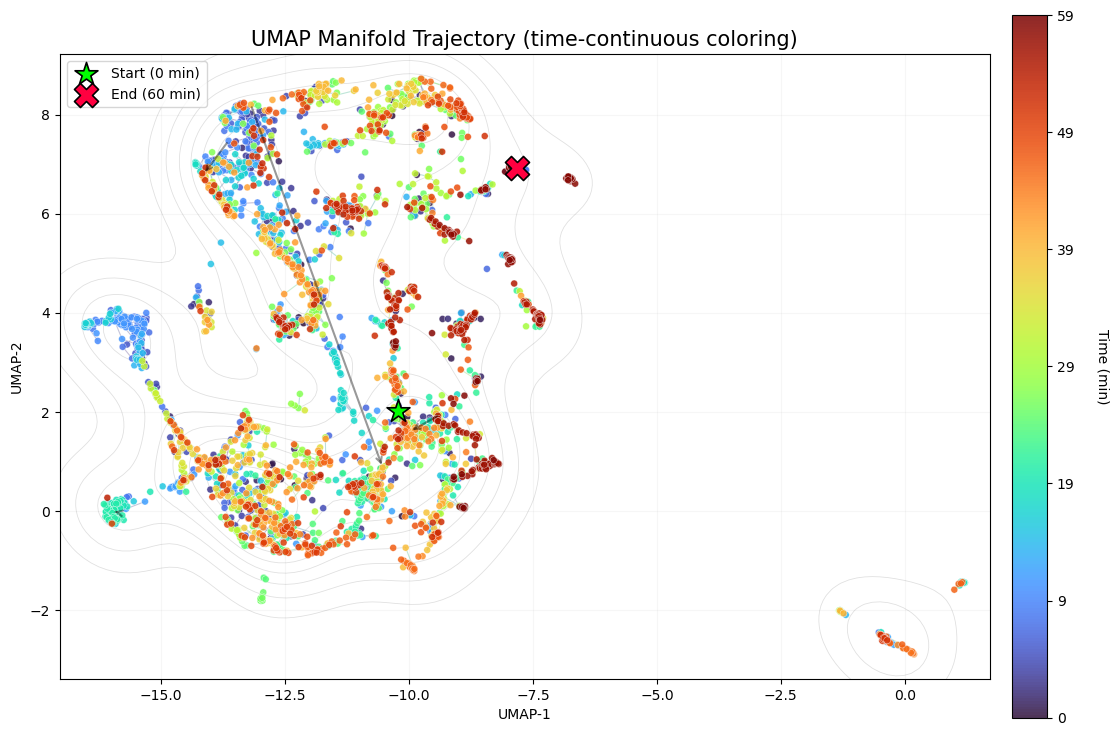

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from scipy.stats import gaussian_kde
import umap

# ==================== 数据准备（替换为你的真实数据） ====================
fs = 100; W_sec = 2; stride_sec = 1
W = int(fs * W_sec); stride = int(fs * stride_sec)

X = data3_aligned


def sliding_window(data, window_size, stride):
    n_samples = int((len(data) - window_size) // stride + 1)
    return np.array([data[i*stride : i*stride + window_size].flatten() 
                     for i in range(n_samples)])

patches = sliding_window(X, W, stride)
patches_scaled = StandardScaler().fit_transform(patches)

# ==================== UMAP ====================
reducer = umap.UMAP(n_components=2, n_neighbors=8, min_dist=0.05, 
                    random_state=42, metric='euclidean')
Z = reducer.fit_transform(patches_scaled)

# ==================== 改进可视化：渐变色时间 + 清晰结构 ====================
fig, ax = plt.subplots(figsize=(12, 12))

# --- 1. 背景密度等高线（显示流形骨架）---
kde = gaussian_kde(Z.T)
xmin, xmax = Z[:, 0].min() - 0.5, Z[:, 0].max() + 0.5
ymin, ymax = Z[:, 1].min() - 0.5, Z[:, 1].max() + 0.5
xi, yi = np.mgrid[xmin:xmax:120j, ymin:ymax:120j]
zi = kde(np.vstack([xi.ravel(), yi.ravel()])).reshape(xi.shape)
ax.contour(xi, yi, zi, levels=10, colors='black', alpha=0.12, linewidths=0.6)

# --- 2. 极严格局部连线：只连接低维距离 < 50分位数的相邻点 ---
# 这样只保留最平滑的局部轨迹，消除长距离跳跃的杂乱线
dists = np.linalg.norm(Z[1:] - Z[:-1], axis=1)
threshold = np.percentile(dists, 50)  # 50分位数，只连最平滑的部分

for i in range(len(Z) - 1):
    if dists[i] < threshold:
        # 连线颜色也随时间渐变，与点一致
        ax.plot(Z[i:i+2, 0], Z[i:i+2, 1], 
                color=plt.cm.viridis(i / len(Z)), 
                alpha=0.3, 
                linewidth=0.8)

# --- 3. 渐变色散点（时间连续映射）---
# 使用 turbo/viridis colormap，时间从0到1映射
time_colors = np.arange(len(Z))
scatter = ax.scatter(Z[:, 0], Z[:, 1], 
                     c=time_colors, 
                     cmap='turbo',   # turbo比plasma更鲜明，时间分辨更好
                     s=25,           # 稍大的点
                     alpha=0.85,
                     edgecolors='white',  # 白边增加分离度
                     linewidths=0.3,
                     zorder=3)

# --- 4. 起点和终点醒目标注 ---
ax.scatter(Z[0, 0], Z[0, 1], color='#00FF00', s=300, marker='*', 
           edgecolors='black', linewidths=1.2, zorder=5, label='Start (0 min)')
ax.scatter(Z[-1, 0], Z[-1, 1], color='#FF0040', s=300, marker='X', 
           edgecolors='black', linewidths=1.2, zorder=5, label='End (60 min)')

# --- 5. 添加方向箭头（每10分钟一个，显示演化方向）---
arrow_interval = int(10 * 60 / stride_sec)  # 每10分钟一个箭头
for i in range(arrow_interval, len(Z) - arrow_interval, arrow_interval):
    dx = Z[i+5, 0] - Z[i, 0]
    dy = Z[i+5, 1] - Z[i, 1]
    norm = np.sqrt(dx**2 + dy**2)
    if norm > 0.01:
        ax.annotate('', xy=(Z[i+5, 0], Z[i+5, 1]), xytext=(Z[i, 0], Z[i, 1]),
                    arrowprops=dict(arrowstyle='->', color='black', 
                                   lw=1.5, alpha=0.4))

# --- 6. 装饰 ---
ax.set_aspect('equal')
ax.set_title('UMAP Manifold Trajectory (time-continuous coloring)', fontsize=15)
ax.set_xlabel('UMAP-1')
ax.set_ylabel('UMAP-2')

cbar = plt.colorbar(scatter, ax=ax, shrink=0.6, pad=0.02)
cbar.set_label('Time (min)', rotation=270, labelpad=25)
# 设置colorbar刻度为分钟
n_ticks = 7
cbar.set_ticks(np.linspace(0, len(Z), n_ticks))
cbar.set_ticklabels([f'{int(i*stride_sec/60)}' for i in np.linspace(0, len(Z), n_ticks)])

ax.legend(loc='upper left', fontsize=10)
ax.grid(True, alpha=0.1)
plt.tight_layout()
plt.show()

窗口数: 3596, 联合维度: 3000


d:\Anaconda3\envs\Machinelearning\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
d:\Anaconda3\envs\Machinelearning\Lib\site-packages\sklearn\manifold\_spectral_embedding.py:324: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(


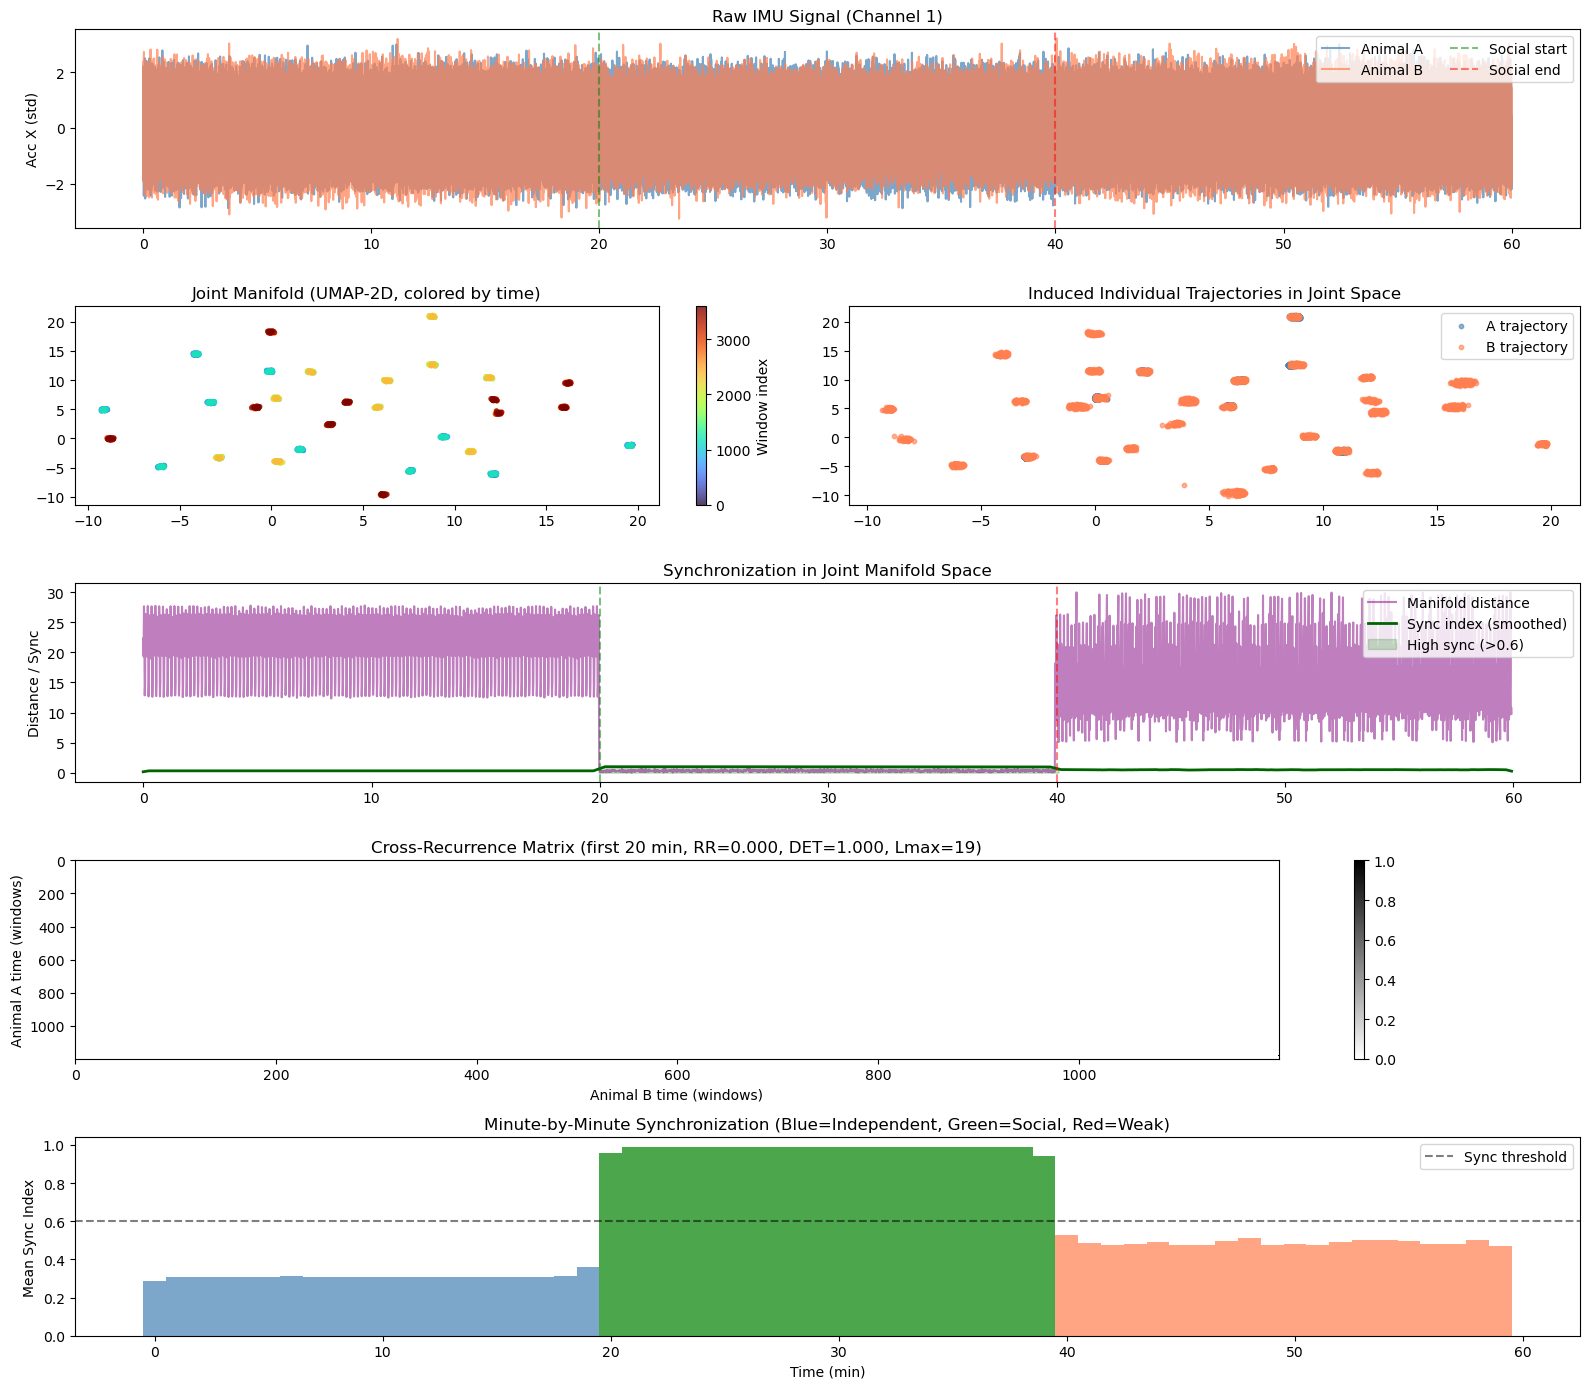


CROSS-RECURRENCE QUANTIFICATION ANALYSIS
Recurrence Rate (RR):     0.0004
Determinism (DET):        1.0000
Max Diagonal Length:      19
Mean Manifold Distance (0-20min):  20.6574
Mean Manifold Distance (20-40min): 0.3636
Mean Manifold Distance (40-60min): 15.2881


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsRegressor
import umap

# ==================== 参数设置 ====================
fs = 50               # IMU采样率 50Hz
T_min = 60            # 总时长 60分钟
n = fs * T_min * 60   # 总采样点数
W_sec = 5             # 窗口5秒（IMU行为片段通常较短）
stride_sec = 1        # 步长1秒，高时间分辨率
W = int(fs * W_sec)
stride = int(fs * stride_sec)

# ==================== 模拟双动物6轴IMU数据 ====================
# 6列 = [acc_x, acc_y, acc_z, gyro_x, gyro_y, gyro_z]
np.random.seed(42)
t = np.arange(n) / fs

# --- 动物A：基础运动信号（主导者）---
X_A = np.zeros((n, 6))
# 加速度：低频基础运动 + 中频探索 + 噪声
for c in range(3):
    X_A[:, c] += 1.0 * np.sin(2*np.pi*(0.5 + c*0.2)*t)      # 慢速姿态变化
    X_A[:, c] += 0.5 * np.sin(2*np.pi*(3 + c)*t)             # 中频运动
    X_A[:, c] += 0.3 * np.random.randn(n)
# 陀螺仪：比加速度高频
for c in range(3, 6):
    X_A[:, c] += 0.8 * np.sin(2*np.pi*(2 + c*0.5)*t)
    X_A[:, c] += 0.4 * np.sin(2*np.pi*(8 + c)*t)
    X_A[:, c] += 0.2 * np.random.randn(n)

# --- 动物B：分三段模拟不同社交情境 ---
X_B = np.zeros((n, 6))

# 时段1：0-20min，独立活动（与A无关，不同频率）
t1 = t < 1200
for c in range(6):
    X_B[t1, c] += 0.8 * np.sin(2*np.pi*(1.2 + c*0.3)*t[t1])
    X_B[t1, c] += 0.3 * np.random.randn(t1.sum())

# 时段2：20-40min，社交同步（B模仿A，带0.5秒延迟+加噪声）
t2 = (t >= 1200) & (t < 2400)
delay = int(0.5 * fs)  # 0.5秒延迟
for c in range(6):
    # B的信号 = 延迟后的A + 社交情境下的协调噪声（相关噪声）
    delayed_A = np.roll(X_A[:, c], delay)
    X_B[t2, c] = 0.7 * delayed_A[t2] + 0.4 * np.random.randn(t2.sum())
    # 加入一点"社交特有"的互相关：A和B的加速度差趋于稳定（靠近）
    X_B[t2, c] += 0.3 * (X_A[t2, c] - X_B[t2, c])  # 收敛耦合项

# 时段3：40-60min，独立活动但偶尔受A干扰（弱耦合）
t3 = t >= 2400
for c in range(6):
    X_B[t3, c] += 0.8 * np.sin(2*np.pi*(0.8 + c*0.4)*t[t3])
    X_B[t3, c] += 0.3 * np.random.randn(t3.sum())
    # 偶尔（每5分钟一次，持续3秒）被A吸引
    for pulse in range(2400, 3600, 300):
        idx = (t >= pulse) & (t < pulse + 3)
        X_B[idx, c] += 0.4 * X_A[idx, c]

# Z-score标准化（逐通道，跨动物分别标准化）
scaler_A = StandardScaler()
scaler_B = StandardScaler()
X_A = scaler_A.fit_transform(X_A)
X_B = scaler_B.fit_transform(X_B)

# ==================== 1. 滑动窗口 ====================
def sliding_window(data, window_size, stride):
    n_samples = int((len(data) - window_size) // stride + 1)
    return np.array([data[i*stride : i*stride + window_size].flatten() 
                     for i in range(n_samples)])

patches_A = sliding_window(X_A, W, stride)
patches_B = sliding_window(X_B, W, stride)
n_windows = patches_A.shape[0]

# 拼接为联合向量：每个窗口包含双动物完整运动信息
patches_joint = np.concatenate([patches_A, patches_B], axis=1)
print(f"窗口数: {n_windows}, 联合维度: {patches_joint.shape[1]}")

# ==================== 2. 联合UMAP降维 ====================
# 每个点代表"双动物在t时刻的联合运动状态"
reducer = umap.UMAP(n_components=3, n_neighbors=15, min_dist=0.1,
                    random_state=42, metric='euclidean')
Z_joint = reducer.fit_transform(patches_joint)

# ==================== 3. 反解：从联合嵌入恢复个体子轨迹 ====================
# 核心思想：训练KNN回归器，学习 Z_joint -> 个体原始特征 的映射
# 然后用回归器预测"如果只有A运动，联合嵌入会是什么样"

# 3.1 为A构建诱导轨迹
knn_A = KNeighborsRegressor(n_neighbors=10, weights='distance')
knn_A.fit(Z_joint, patches_A)
# 预测A的特征（从联合嵌入中"提取"A的成分）
patches_A_induced = knn_A.predict(Z_joint)
# 将A的诱导特征重新嵌入到联合流形（近似）
Z_A_induced = reducer.transform(
    np.concatenate([patches_A_induced, np.zeros_like(patches_B)], axis=1)
)

# 3.2 为B构建诱导轨迹
knn_B = KNeighborsRegressor(n_neighbors=10, weights='distance')
knn_B.fit(Z_joint, patches_B)
patches_B_induced = knn_B.predict(Z_joint)
Z_B_induced = reducer.transform(
    np.concatenate([np.zeros_like(patches_A), patches_B_induced], axis=1)
)

# ==================== 4. 同步性分析 ====================
# 4.1 联合流形中的轨迹距离（越低表示越同步）
manifold_dist = np.linalg.norm(Z_A_induced - Z_B_induced, axis=1)

# 4.2 交叉递归分析（简化版CRQA）
# 构建交叉递归矩阵：两轨迹在联合空间中何时靠近
epsilon = np.percentile(manifold_dist, 25)  # 用25分位数作为阈值
CR = np.zeros((n_windows, n_windows))
for i in range(n_windows):
    # 只比较时间邻近的窗口（避免时间无关的虚假递归）
    for j in range(max(0, i-30), min(n_windows, i+30)):
        if np.linalg.norm(Z_A_induced[i] - Z_B_induced[j]) < epsilon:
            CR[i, j] = 1

# 4.3 递归量化指标
RR = CR.mean()  # 递归率
# 对角线统计（同步持续时间）
diag_lengths = []
for k in range(-n_windows+1, n_windows):
    diag = np.diag(CR, k=k)
    if diag.sum() == 0:
        continue
    # 连续1的长度
    runs = []
    current = 0
    for v in diag:
        if v == 1:
            current += 1
        else:
            if current > 0:
                runs.append(current)
            current = 0
    if current > 0:
        runs.append(current)
    diag_lengths.extend(runs)

DET = sum(diag_lengths) / CR.sum() if CR.sum() > 0 else 0  # 确定性
L_max = max(diag_lengths) if diag_lengths else 0

# 4.4 瞬时同步指数（滑动窗口平滑）
sync_index = 1 - (manifold_dist / manifold_dist.max())
sync_smooth = np.convolve(sync_index, np.ones(30)/30, mode='same')

# ==================== 5. 可视化 ====================
fig = plt.figure(figsize=(16, 14))

# --- 5.1 原始信号（A和B的第一通道）---
ax1 = fig.add_subplot(5, 1, 1)
time_min = np.arange(n) / fs / 60
ax1.plot(time_min, X_A[:, 0], alpha=0.7, color='steelblue', label='Animal A')
ax1.plot(time_min, X_B[:, 0], alpha=0.7, color='coral', label='Animal B')
ax1.axvline(20, color='green', linestyle='--', alpha=0.5, label='Social start')
ax1.axvline(40, color='red', linestyle='--', alpha=0.5, label='Social end')
ax1.set_ylabel('Acc X (std)')
ax1.set_title('Raw IMU Signal (Channel 1)')
ax1.legend(ncol=2, loc='upper right')

# --- 5.2 联合流形3D投影（2D展示）---
ax2 = fig.add_subplot(5, 2, 3)
scatter = ax2.scatter(Z_joint[:, 0], Z_joint[:, 1], c=np.arange(n_windows),
                      cmap='turbo', s=15, alpha=0.8, edgecolors='none')
ax2.set_title('Joint Manifold (UMAP-2D, colored by time)')
plt.colorbar(scatter, ax=ax2, label='Window index')

# --- 5.3 A vs B 诱导轨迹对比 ---
ax3 = fig.add_subplot(5, 2, 4)
ax3.scatter(Z_A_induced[:, 0], Z_A_induced[:, 1], c='steelblue', s=10, alpha=0.6, label='A trajectory')
ax3.scatter(Z_B_induced[:, 0], Z_B_induced[:, 1], c='coral', s=10, alpha=0.6, label='B trajectory')
ax3.set_title('Induced Individual Trajectories in Joint Space')
ax3.legend()

# --- 5.4 流形距离时间线（同步度）---
ax4 = fig.add_subplot(5, 1, 3)
window_time = np.arange(n_windows) * stride_sec / 60
ax4.plot(window_time, manifold_dist, color='purple', alpha=0.5, label='Manifold distance')
ax4.plot(window_time, sync_smooth, color='darkgreen', linewidth=2, label='Sync index (smoothed)')
ax4.axvline(20, color='green', linestyle='--', alpha=0.5)
ax4.axvline(40, color='red', linestyle='--', alpha=0.5)
ax4.fill_between(window_time, 0, sync_smooth, where=(sync_smooth > 0.6),
                 color='green', alpha=0.2, label='High sync (>0.6)')
ax4.set_ylabel('Distance / Sync')
ax4.set_title('Synchronization in Joint Manifold Space')
ax4.legend(loc='upper right')

# --- 5.5 交叉递归矩阵（局部）---
ax5 = fig.add_subplot(5, 1, 4)
# 只显示前20分钟（独立）和中间20分钟（社交）的对比
n_show = 20 * 60  # 20分钟的窗口数
im = ax5.imshow(CR[:n_show, :n_show], cmap='binary', aspect='auto', interpolation='nearest')
ax5.set_title(f'Cross-Recurrence Matrix (first 20 min, RR={RR:.3f}, DET={DET:.3f}, Lmax={L_max})')
ax5.set_xlabel('Animal B time (windows)')
ax5.set_ylabel('Animal A time (windows)')
plt.colorbar(im, ax=ax5)

# --- 5.6 分时段统计 ---
ax6 = fig.add_subplot(5, 1, 5)
# 计算每分钟的平均同步度
min_sync = []
for m in range(T_min):
    idx = (window_time >= m) & (window_time < m+1)
    if idx.sum() > 0:
        min_sync.append(sync_smooth[idx].mean())
    else:
        min_sync.append(0)
min_sync = np.array(min_sync)

colors = ['steelblue' if m < 20 else 'green' if m < 40 else 'coral' 
          for m in range(T_min)]
ax6.bar(range(T_min), min_sync, color=colors, alpha=0.7, width=1.0)
ax6.axhline(0.6, color='black', linestyle='--', alpha=0.5, label='Sync threshold')
ax6.set_xlabel('Time (min)')
ax6.set_ylabel('Mean Sync Index')
ax6.set_title('Minute-by-Minute Synchronization (Blue=Independent, Green=Social, Red=Weak)')
ax6.legend()

plt.tight_layout()
plt.show()

# ==================== 6. 结果输出 ====================
print("\n" + "="*50)
print("CROSS-RECURRENCE QUANTIFICATION ANALYSIS")
print("="*50)
print(f"Recurrence Rate (RR):     {RR:.4f}")
print(f"Determinism (DET):        {DET:.4f}")
print(f"Max Diagonal Length:      {L_max}")
print(f"Mean Manifold Distance (0-20min):  {manifold_dist[:1200].mean():.4f}")
print(f"Mean Manifold Distance (20-40min): {manifold_dist[1200:2400].mean():.4f}")
print(f"Mean Manifold Distance (40-60min): {manifold_dist[2400:].mean():.4f}")
print("="*50)